# 01  -  Data Profiling**Purpose:** understand the Olist export before modelling it, and quantify the fourknown traps so the design decisions in the development plan are backed by numbersfrom this dataset rather than by received wisdom.**Reads from:** the `olist_raw` layer. This is the only notebook that touches raw  - the other two read from marts, as they must.**Definition of done:** `docs/data_dictionary.md` is complete, and each of the fourtraps below has a number attached to it.

In [1]:
# warehouse.py lives at the repository root so the notebooks and the Streamlit
# dashboard share one definition of which datasets to read. Walk up from the
# working directory to find it, so the notebook runs the same whether it is
# opened in Jupyter or executed headless by `make analyse`.
import sys, pathlib
_root = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "warehouse.py").exists())
sys.path.insert(0, str(_root))

import pandas as pd
import matplotlib.pyplot as plt

from warehouse import q, marts, staging, raw, style_charts, describe_connection, SNAPSHOT_DATE

style_charts()
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

print(describe_connection())

/Users/timkoo/miniconda3/envs/bd-m2-g7/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.6.0)/charset_normalizer (3.5.1) doesn't match a supported version!
  warnings.warn(


project=olist-group7  location=US  target=dev
marts dataset=dbt_TK_marts
analytical snapshot date=2018-10-17


## 1. Volume and shapeRow counts are reconciled against the manifest by `make ingest`; this is a second,independent look from inside the warehouse.

In [2]:
tables = [
    "orders", "order_items", "order_payments", "order_reviews",
    "customers", "products", "sellers", "geolocation",
    "product_category_translation",
]

counts = q(" union all ".join(
    f"select '{t}' as table_name, count(*) as row_count from {raw(t)}" for t in tables
) + " order by row_count desc")

counts["row_count"] = counts["row_count"].astype(int)
display(counts)
print(f"total rows: {counts.row_count.sum():,}")

/Users/timkoo/miniconda3/envs/bd-m2-g7/lib/python3.11/site-packages/google/cloud/bigquery/client.py:613: UserWarning: Cannot create BigQuery Storage client, the dependency google-cloud-bigquery-storage is not installed.
  warnings.warn(


,table_name,row_count
0,geolocation,1000163
1,order_items,112650
2,order_payments,103886
3,orders,99441
4,customers,99441
5,order_reviews,99224
6,products,32951
7,sellers,3095
8,product_category_translation,71


total rows: 1,550,922


## 2. Coverage windowThe export is sparse at both ends. Establishing exactly where usable coverage startsand stops is what stops the monthly trend chart being read as a demand collapse.

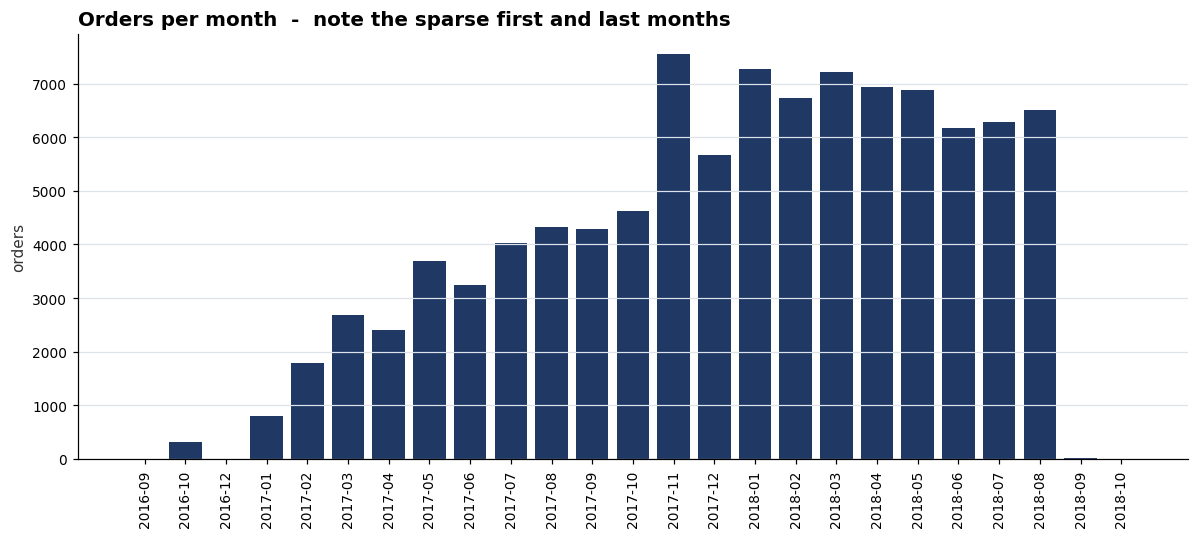

first month: {'year_month': '2016-09', 'orders': 4}
last month : {'year_month': '2018-10', 'orders': 4}

Months with fewer than 500 orders (excluded or annotated in every chart):


,year_month,orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
23,2018-09,16
24,2018-10,4


In [3]:
coverage = q(f"""
    select
        format_date('%Y-%m', date(order_purchase_timestamp)) as year_month,
        count(*) as orders
    from {raw('orders')}
    group by year_month
    order by year_month
""")

fig, ax = plt.subplots()
ax.bar(coverage.year_month, coverage.orders, color="#1f3864")
ax.set_title("Orders per month  -  note the sparse first and last months")
ax.set_ylabel("orders")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("first month:", coverage.iloc[0].to_dict())
print("last month :", coverage.iloc[-1].to_dict())
print()
print("Months with fewer than 500 orders (excluded or annotated in every chart):")
display(coverage[coverage.orders < 500])

## 3. Null rates on the columns the business case depends onA null delivery timestamp is not a cosmetic problem here: it removes the order fromthe late-rate denominator. We need to know how many there are, and why.

In [4]:
nulls = q(f"""
    select
        count(*)                                                  as orders,
        countif(order_approved_at is null)                        as null_approved,
        countif(order_delivered_carrier_date is null)             as null_carrier,
        countif(order_delivered_customer_date is null)            as null_delivered,
        countif(order_estimated_delivery_date is null)            as null_promised,
        countif(order_status = 'delivered'
                and order_delivered_customer_date is null)        as delivered_but_no_date
    from {raw('orders')}
""").T.rename(columns={0: "count"})

nulls["pct_of_orders"] = (nulls["count"] / nulls.loc["orders", "count"] * 100).round(2)
display(nulls)

,count,pct_of_orders
orders,99441,100.00
null_approved,160,0.16
null_carrier,1783,1.79
null_delivered,2965,2.98
null_promised,0,0.00
delivered_but_no_date,8,0.01


In [5]:
# Nulls are concentrated in non-delivered statuses, which is expected and benign.
# What matters is the 'delivered but no date' cell above: those orders would
# silently vanish from the late-rate denominator, which is why
# assert_delivered_orders_have_delivery_date.sql exists.
by_status = q(f"""
    select
        order_status,
        count(*)                                        as orders,
        countif(order_delivered_customer_date is null)  as missing_delivery_date
    from {raw('orders')}
    group by order_status
    order by orders desc
""")
display(by_status)

,order_status,orders,missing_delivery_date
0,delivered,96478,8
1,shipped,1107,1107
2,canceled,625,619
3,unavailable,609,609
4,invoiced,314,314
5,processing,301,301
6,created,5,5
7,approved,2,2


## 4. The four traps, quantifiedEach of these justifies a specific fan-out control in the dbt project. The point ofthis section is that none of them is theoretical.

### Trap 1  -  Payment fan-outJoining raw payments to order items multiplies rows. The multiplier below is thefactor by which revenue would be inflated if anyone did that.

In [6]:
fanout = q(f"""
    with items as (
        select order_id, count(*) as item_lines
        from {raw('order_items')} group by order_id
    ),
    pays as (
        select order_id, count(*) as payment_lines
        from {raw('order_payments')} group by order_id
    )
    select
        sum(i.item_lines)                              as correct_item_rows,
        sum(i.item_lines * p.payment_lines)            as rows_after_naive_join,
        countif(p.payment_lines > 1)                   as orders_with_multiple_payments,
        max(p.payment_lines)                           as max_payment_lines
    from items i join pays p using (order_id)
""")
display(fanout)

inflation = fanout.rows_after_naive_join[0] / fanout.correct_item_rows[0]
print(f"A naive payments-to-items join inflates the row count by {inflation:.2f}x.")
print("This is why int_order_payments aggregates to order grain first.")

,correct_item_rows,rows_after_naive_join,orders_with_multiple_payments,max_payment_lines
0,112647,117601,2936,29


A naive payments-to-items join inflates the row count by 1.04x.
This is why int_order_payments aggregates to order grain first.


### Trap 2  -  Review fan-out`review_id` is not unique, and some orders carry more than one review.

In [7]:
reviews = q(f"""
    select
        count(*)                                             as review_rows,
        count(distinct review_id)                            as distinct_review_ids,
        count(distinct order_id)                             as distinct_orders,
        count(*) - count(distinct order_id)                  as excess_rows_per_order
    from {raw('order_reviews')}
""")
display(reviews)
print("Excess rows are orders that would be duplicated by a naive join,")
print("duplicating their revenue and their delivery measures with them.")

,review_rows,distinct_review_ids,distinct_orders,excess_rows_per_order
0,99224,98410,98673,551


Excess rows are orders that would be duplicated by a naive join,
duplicating their revenue and their delivery measures with them.


### Trap 3  -  Customer identity`customer_id` is issued per order. Building RFM on it would make every customer aone-time buyer.

In [8]:
identity = q(f"""
    select
        count(*)                                            as customer_id_rows,
        count(distinct customer_unique_id)                  as actual_people,
        count(*) - count(distinct customer_unique_id)       as duplicate_identities
    from {raw('customers')}
""")
display(identity)

repeat = q(f"""
    select orders_placed, count(*) as customers
    from (
        select customer_unique_id, count(*) as orders_placed
        from {raw('customers')} group by customer_unique_id
    )
    group by orders_placed order by orders_placed
""")
display(repeat)
print("Every row below orders_placed=1 would be invisible if we segmented on customer_id.")

,customer_id_rows,actual_people,duplicate_identities
0,99441,96096,3345


,orders_placed,customers
0,1,93099
1,2,2745
2,3,203
3,4,30
4,5,8
5,6,6
6,7,3
7,9,1
8,17,1


Every row below orders_placed=1 would be invisible if we segmented on customer_id.


### Trap 4  -  Geolocation cardinality

In [9]:
geo = q(f"""
    select
        count(*)                                          as geolocation_rows,
        count(distinct geolocation_zip_code_prefix)       as distinct_prefixes,
        round(count(*) / count(distinct geolocation_zip_code_prefix), 1)
                                                          as avg_rows_per_prefix
    from {raw('geolocation')}
""")
display(geo)
print("Joining this table raw to customers would multiply the row count by")
print(f"roughly {geo.avg_rows_per_prefix[0]}x. stg_geolocation collapses it first.")

,geolocation_rows,distinct_prefixes,avg_rows_per_prefix
0,1000163,19015,52.6


Joining this table raw to customers would multiply the row count by
roughly 52.6x. stg_geolocation collapses it first.


## 5. Referential integrityOrphan keys would silently drop rows from the star schema. Checked here so the`relationships` tests in dbt are confirming something we already understand ratherthan discovering it late.

In [10]:
orphans = q(f"""
    select 'order_items -> orders'   as relationship,
           countif(o.order_id is null) as orphans, count(*) as total
    from {raw('order_items')} i left join {raw('orders')} o using (order_id)
    union all
    select 'order_items -> products',
           countif(p.product_id is null), count(*)
    from {raw('order_items')} i left join {raw('products')} p using (product_id)
    union all
    select 'order_items -> sellers',
           countif(s.seller_id is null), count(*)
    from {raw('order_items')} i left join {raw('sellers')} s using (seller_id)
    union all
    select 'orders -> customers',
           countif(c.customer_id is null), count(*)
    from {raw('orders')} o left join {raw('customers')} c using (customer_id)
    union all
    select 'orders without any item line',
           countif(i.order_id is null), count(*)
    from {raw('orders')} o left join (select distinct order_id from {raw('order_items')}) i using (order_id)
""")
orphans["orphan_pct"] = (orphans.orphans / orphans.total * 100).round(3)
display(orphans)

,relationship,orphans,total,orphan_pct
0,order_items -> orders,0,112650,0.000
1,order_items -> products,0,112650,0.000
2,order_items -> sellers,0,112650,0.000
3,orders -> customers,0,99441,0.000
4,orders without any item line,775,99441,0.779


## 6. Delivery measures  -  a first lookA sanity check on the raw milestones before any modelling. Impossible values herewould mean the timestamps cannot be trusted at all.

In [12]:
delivery = q(f"""
    select
        countif(order_status = 'delivered')                                     as delivered_orders,
        round(avg(date_diff(date(order_delivered_customer_date),
                            date(order_purchase_timestamp), day)), 2)           as avg_delivery_days,
        round(avg(date_diff(date(order_delivered_customer_date),
                            date(order_estimated_delivery_date), day)), 2)      as avg_delay_vs_promise,
        countif(date(order_delivered_customer_date)
                > date(order_estimated_delivery_date))                          as late_orders,
        countif(order_delivered_customer_date < order_purchase_timestamp)       as impossible_delivered_before_purchase,
        countif(order_delivered_carrier_date  < order_approved_at)              as impossible_carrier_before_approval
    from {raw('orders')}
    where order_status = 'delivered'
""")
display(delivery.T.rename(columns={0: "value"}))

late_rate = delivery.late_orders[0] / delivery.delivered_orders[0]
print(f"\nHeadline: {late_rate:.1%} of delivered orders arrived after the promised date.")
print("Note the two 'impossible' counters: they are the reason")
print("assert_delivery_milestones_in_order.sql runs at error severity.")

,value
delivered_orders,96478.00
avg_delivery_days,12.50
avg_delay_vs_promise,-11.88
late_orders,6534.00
impossible_delivered_before_purchase,0.00
impossible_carrier_before_approval,1350.00



Headline: 6.8% of delivered orders arrived after the promised date.
Note the two 'impossible' counters: they are the reason
assert_delivery_milestones_in_order.sql runs at error severity.


## Findings to carry into the data dictionaryFill this in from the numbers above before closing Phase 2:| Finding | Number | Consequence for the design ||---|---|---|| Payment fan-out multiplier | | `int_order_payments` aggregates to order grain || Orders with multiple reviews | | `int_order_reviews` deduplicates to one per order || customer_id rows vs actual people | | `dim_customer` keys on `customer_unique_id` || Geolocation rows per zip prefix | | `stg_geolocation` collapses before any join || Delivered orders with no delivery date | | excluded from the late-rate denominator, tested || Usable coverage window | | charts trim or annotate the sparse edge months |